# Public CRE HPO Presentation Summary

This notebook turns the recent `src/learn` HPO registry into presentation-ready plots for three public pretraining-style tasks:

- deBoer core promoter activity
- Hani 5'UTR Library 1 RNA activity
- Hani 3'UTR Library 1 RNA activity

For the UTR tasks, held-out test metrics are present in `runs.csv`, so the notebook selects models by the validation checkpoint metric and then reports test performance. For promoter, the current registry does not include populated test metrics, so promoter comparisons are validation-only.

The UTR comparison section is intentionally framed as one-cell scalar activity prediction, because the local configs use only `target_cell_type: c2` (HepG2) rather than the six-cell activity/specificity modeling used by PARADE.

In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
except Exception:
    sns = None

warnings.filterwarnings("ignore", category=FutureWarning)


def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "boda2_EU" / "src" / "learn" / "run_registry" / "runs.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing boda2_EU/src/learn/run_registry/runs.csv")


REPO_ROOT = find_repo_root(Path.cwd())
RUNS_CSV = REPO_ROOT / "boda2_EU" / "src" / "learn" / "run_registry" / "runs.csv"
OUT_DIR = REPO_ROOT / "boda2_EU" / "tutorials" / "lib1_tasks" / "pretraining_CRE_public_data" / "presentation_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

REGION_LABELS = {
    "promoter": "Promoter",
    "utr5": "5'UTR",
    "utr3": "3'UTR",
}
REGION_ORDER = ["Promoter", "5'UTR", "3'UTR"]
REGION_COLORS = {
    "Promoter": "#2F5D7C",
    "5'UTR": "#1B9E77",
    "3'UTR": "#C44E52",
}
PHASE_COLORS = {
    "Scratch / broad HPO": "#7C8A99",
    "Focused HPO": "#E6A23C",
}

print(f"Repo root: {REPO_ROOT}")
print(f"Run registry: {RUNS_CSV.relative_to(REPO_ROOT)}")
print(f"Plot output: {OUT_DIR.relative_to(REPO_ROOT)}")

Repo root: /home/minhang/synBio_AL
Run registry: boda2_EU/src/learn/run_registry/runs.csv
Plot output: boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots


## Load And Filter Runs

The analysis below keeps only completed 2026 registry rows for the public promoter and Hani UTR activity tasks. The polysome 5'UTR run is intentionally excluded from the main UTR comparison because it is a different dataset and objective.

In [2]:
runs = pd.read_csv(RUNS_CSV)

numeric_cols = [
    "best_epoch", "best_metric_value", "val_loss", "val_r2", "val_pearson", "val_spearman",
    "test_loss", "test_r2", "test_pearson", "test_spearman",
    "train_loss", "train_r2", "train_pearson", "train_spearman",
]
for col in numeric_cols:
    runs[col] = pd.to_numeric(runs[col], errors="coerce")

runs["timestamp"] = pd.to_datetime(runs["timestamp"], errors="coerce")

mask = (
    ((runs["task_family"].eq("promoter")) & runs["target_family"].eq("deboer_core")) |
    ((runs["task_family"].isin(["utr5", "utr3"])) & runs["target_family"].eq("hani_rna_activity"))
)
public_runs = runs.loc[mask & runs["status"].eq("completed")].copy()
public_runs = public_runs[public_runs["timestamp"].dt.year.eq(2026)].copy()
public_runs["region"] = public_runs["task_family"].map(REGION_LABELS)
public_runs["search_phase"] = np.where(
    public_runs["comparison_group"].str.contains("focused", case=False, na=False),
    "Focused HPO",
    "Scratch / broad HPO",
)
public_runs["model_label"] = public_runs["model_module"].replace({
    "UTR_BassetVL": "UTR-BassetVL",
    "BassetVL": "BassetVL",
    "ResNet1DRegressor": "ResNet1D",
})
public_runs["checkpoint_metric"] = public_runs["best_metric_value"]
public_runs["test_available"] = public_runs["test_r2"].notna()

inventory = (
    public_runs
    .groupby(["region", "search_phase", "model_label"], observed=True)
    .agg(n_runs=("run_id", "nunique"), first_run=("timestamp", "min"), last_run=("timestamp", "max"))
    .reset_index()
    .sort_values(["region", "search_phase", "model_label"])
)

display(inventory)
print(f"Total filtered runs: {len(public_runs)}")

,region,search_phase,model_label,n_runs,first_run,last_run
0,3'UTR,Scratch / broad HPO,UTR-BassetVL,18,2026-04-20 12:49:00,2026-04-21 05:53:20
1,5'UTR,Focused HPO,UTR-BassetVL,12,2026-04-26 00:52:57,2026-04-26 01:53:45
2,5'UTR,Scratch / broad HPO,UTR-BassetVL,18,2026-04-19 22:02:34,2026-04-21 05:58:12
3,Promoter,Focused HPO,UTR-BassetVL,11,2026-04-27 03:02:08,2026-04-27 06:15:56
4,Promoter,Scratch / broad HPO,BassetVL,17,2026-04-20 14:56:00,2026-04-21 08:53:58
5,Promoter,Scratch / broad HPO,ResNet1D,17,2026-04-20 13:36:06,2026-04-21 15:47:01
6,Promoter,Scratch / broad HPO,UTR-BassetVL,17,2026-04-19 21:51:28,2026-04-21 14:06:07


Total filtered runs: 110


## Winner Tables

`checkpoint_metric` is the metric used by the checkpoint callback. Most of the new sweeps monitor validation Pearson r squared (`epoch_end_val_pearson_r2`). I keep that value for HPO ranking and show the separately logged validation and test metrics beside it.

In [3]:
def best_by(df: pd.DataFrame, group_cols, metric: str, ascending=False) -> pd.DataFrame:
    usable = df[df[metric].notna()].copy()
    return (
        usable.sort_values([*group_cols, metric, "timestamp"], ascending=[*[True] * len(group_cols), ascending, False])
        .groupby(group_cols, as_index=False, group_keys=False)
        .head(1)
    )

validation_winners = best_by(public_runs, ["region"], "checkpoint_metric", ascending=False)
phase_winners = best_by(public_runs, ["region", "search_phase"], "checkpoint_metric", ascending=False)
test_winners = best_by(public_runs[public_runs["task_family"].isin(["utr5", "utr3"])], ["region"], "test_r2", ascending=False)

headline_cols = [
    "region", "run_id", "search_phase", "model_label", "checkpoint_metric", "val_r2", "val_pearson",
    "test_r2", "test_pearson", "best_epoch", "timestamp", "notes",
]
headline = validation_winners[headline_cols].copy().sort_values("region", key=lambda s: s.map({r: i for i, r in enumerate(REGION_ORDER)}))
headline["timestamp"] = headline["timestamp"].dt.strftime("%Y-%m-%d %H:%M")

print("Validation-selected region winners")
display(headline)

print("UTR test-set leaders, shown for transparency rather than HPO selection")
display(
    test_winners[headline_cols]
    .copy()
    .sort_values("region", key=lambda s: s.map({r: i for i, r in enumerate(REGION_ORDER)}))
    .assign(timestamp=lambda d: d["timestamp"].dt.strftime("%Y-%m-%d %H:%M"))
)

headline.to_csv(OUT_DIR / "validation_selected_region_winners.csv", index=False)
test_winners[headline_cols].to_csv(OUT_DIR / "utr_test_set_leaders.csv", index=False)

Validation-selected region winners


,region,run_id,search_phase,model_label,checkpoint_metric,val_r2,val_pearson,test_r2,test_pearson,best_epoch,timestamp,notes
12,Promoter,u0n4yr9b,Scratch / broad HPO,UTR-BassetVL,0.424880,0.420291,0.648272,NaN,NaN,45,2026-04-21 01:48,promoter_arch_screen_v1
19,5'UTR,84hnad9t,Scratch / broad HPO,UTR-BassetVL,0.587846,0.572430,0.756537,0.525984,0.725411,100,2026-04-21 02:17,utr5_baseline_hpo_v1
51,3'UTR,re8nopvn,Scratch / broad HPO,UTR-BassetVL,0.498124,0.487834,0.698351,0.453911,0.673881,71,2026-04-21 05:13,utr3_baseline_hpo_v1


UTR test-set leaders, shown for transparency rather than HPO selection


,region,run_id,search_phase,model_label,checkpoint_metric,val_r2,val_pearson,test_r2,test_pearson,best_epoch,timestamp,notes
100,5'UTR,0k3yrrxv,Focused HPO,UTR-BassetVL,0.586782,0.576199,0.759218,0.541201,0.735808,26,2026-04-26 01:44,utr5_hani_focused_stage2_v1
34,3'UTR,x7iymef4,Scratch / broad HPO,UTR-BassetVL,0.484857,0.456745,0.675911,0.464475,0.681379,21,2026-04-21 03:47,utr3_baseline_hpo_v1


## Plot 1 - Best Run By Region And Search Phase

This view answers a practical question: did the focused stage improve the previous broad/scratch HPO neighborhood?

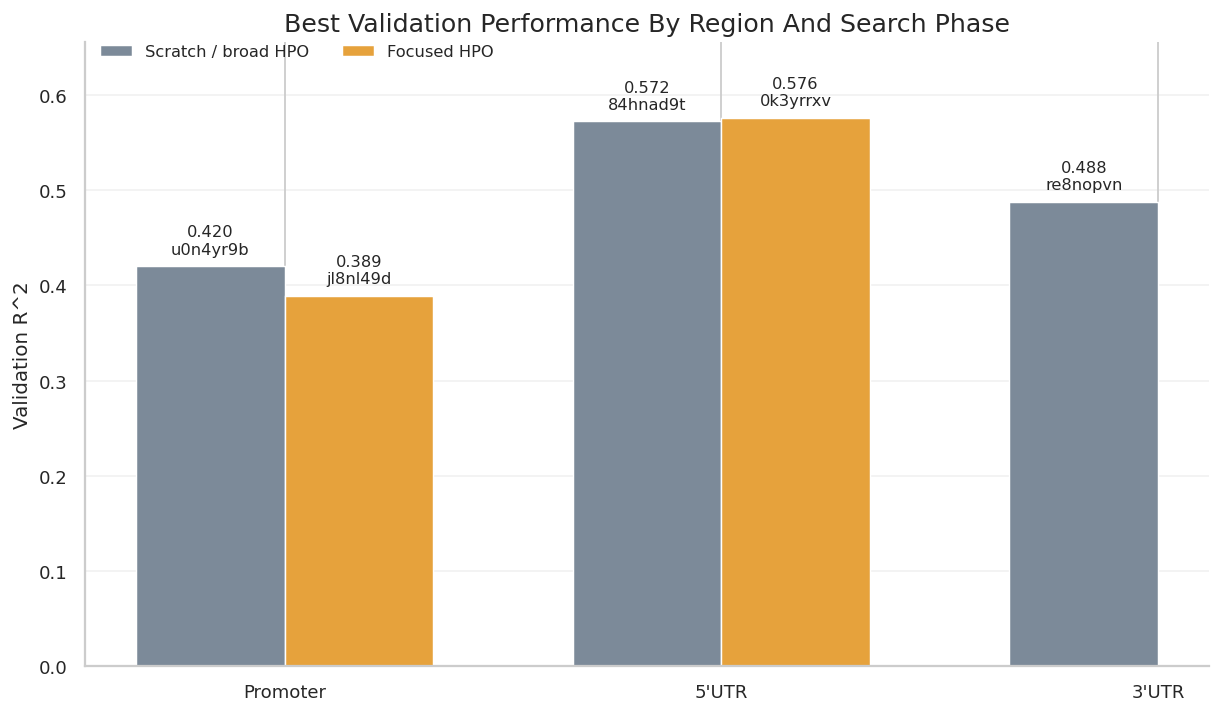

In [4]:
plot_df = phase_winners.copy()
plot_df["region"] = pd.Categorical(plot_df["region"], REGION_ORDER, ordered=True)
plot_df["search_phase"] = pd.Categorical(plot_df["search_phase"], list(PHASE_COLORS), ordered=True)
plot_df = plot_df.sort_values(["region", "search_phase"])

fig, ax = plt.subplots(figsize=(9.5, 5.6))
bar_width = 0.34
x = np.arange(len(REGION_ORDER))

for i, phase in enumerate(PHASE_COLORS):
    sub = plot_df[plot_df["search_phase"].eq(phase)].set_index("region")
    heights = [sub.loc[region, "val_r2"] if region in sub.index else np.nan for region in REGION_ORDER]
    offsets = x + (i - 0.5) * bar_width
    bars = ax.bar(offsets, heights, width=bar_width, color=PHASE_COLORS[phase], label=phase, edgecolor="white", linewidth=0.8)
    for region, bar, height in zip(REGION_ORDER, bars, heights):
        if np.isfinite(height):
            run_id = sub.loc[region, "run_id"]
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.010, f"{height:.3f}\n{run_id}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(REGION_ORDER)
ax.set_ylabel("Validation R^2")
ax.set_title("Best Validation Performance By Region And Search Phase")
ax.set_ylim(0, max(plot_df["val_r2"].max() + 0.08, 0.62))
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0, 1.02), ncol=2)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()

for ext in ["png", "svg"]:
    fig.savefig(OUT_DIR / f"best_validation_by_region_phase.{ext}", bbox_inches="tight")
plt.show()

## Plot 1B - Best Test Performance By Region

This mirrors Plot 1, but ranks by held-out test R^2 and does not split bars by search phase. Promoter is shown as missing because the current promoter export only has train/val rows and no `set == "test"` split.


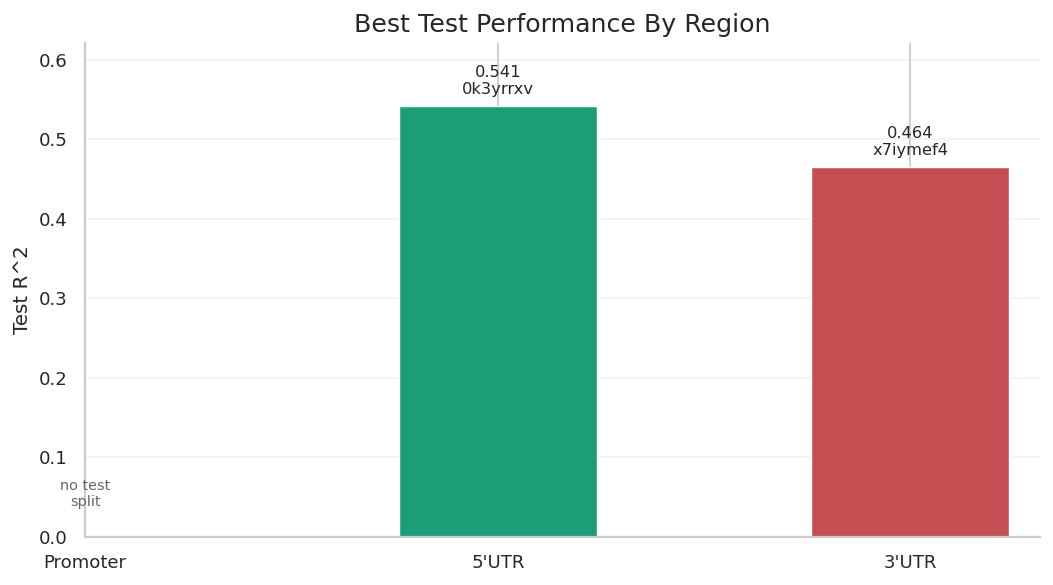

,region,run_id,test_r2,test_pearson,search_phase
0,Promoter,no test split,NaN,NaN,no test split
1,5'UTR,0k3yrrxv,0.541201,0.735808,Focused HPO
2,3'UTR,x7iymef4,0.464475,0.681379,Scratch / broad HPO


In [5]:
test_plot_df = test_winners.copy()
test_plot_df["region"] = pd.Categorical(test_plot_df["region"], REGION_ORDER, ordered=True)
test_plot_df = test_plot_df.sort_values("region")

test_plot_table = []
for region in REGION_ORDER:
    match = test_plot_df[test_plot_df["region"].eq(region)]
    if match.empty:
        test_plot_table.append({
            "region": region,
            "run_id": "no test split",
            "test_r2": np.nan,
            "test_pearson": np.nan,
            "search_phase": "no test split",
        })
    else:
        row = match.iloc[0]
        test_plot_table.append({
            "region": region,
            "run_id": row["run_id"],
            "test_r2": row["test_r2"],
            "test_pearson": row["test_pearson"],
            "search_phase": row["search_phase"],
        })
test_plot_table = pd.DataFrame(test_plot_table)
test_plot_table.to_csv(OUT_DIR / "best_test_performance_by_region.csv", index=False)

fig, ax = plt.subplots(figsize=(8.2, 4.6))
x = np.arange(len(REGION_ORDER))
heights = [
    test_plot_table.loc[test_plot_table["region"].eq(region), "test_r2"].iloc[0]
    for region in REGION_ORDER
]
colors = [REGION_COLORS[region] if np.isfinite(height) else "#D9D9D9" for region, height in zip(REGION_ORDER, heights)]

bars = ax.bar(x, heights, width=0.48, color=colors, edgecolor="white", linewidth=0.8)
for region, bar, height in zip(REGION_ORDER, bars, heights):
    row = test_plot_table[test_plot_table["region"].eq(region)].iloc[0]
    if np.isfinite(height):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.012,
            f"{height:.3f}\n{row['run_id']}",
            ha="center",
            va="bottom",
            fontsize=9,
        )
    else:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            0.035,
            "no test\nsplit",
            ha="center",
            va="bottom",
            fontsize=8,
            color="#666666",
        )

ax.set_xticks(x)
ax.set_xticklabels(REGION_ORDER)
ax.set_ylabel("Test R^2")
ax.set_title("Best Test Performance By Region")
ymax = max(np.nanmax(heights) + 0.08, 0.62) if np.isfinite(heights).any() else 0.62
ax.set_ylim(0, ymax)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()

for ext in ["png", "svg"]:
    fig.savefig(OUT_DIR / f"best_test_performance_by_region.{ext}", bbox_inches="tight")
plt.show()

display(test_plot_table)


## Plot 1C - Best R^2 By Region

This presentation view collapses across HPO phase and held-out split. Each region gets one bar: the highest available R^2 from either validation or test metrics.


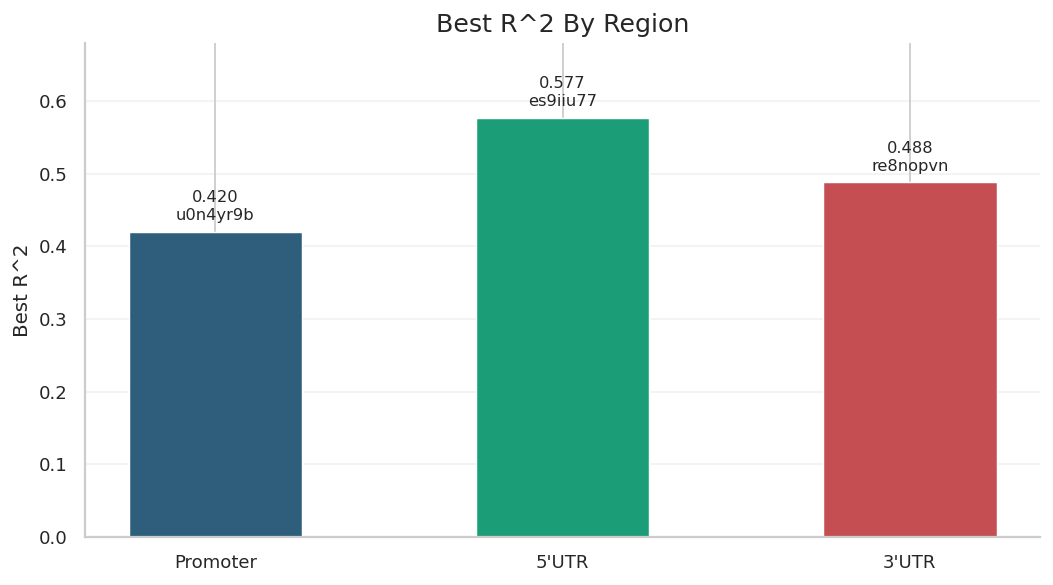

,region,run_id,best_r2
0,Promoter,u0n4yr9b,0.420291
1,5'UTR,es9iiu77,0.577174
2,3'UTR,re8nopvn,0.487834


In [6]:
r2_candidates = []
for metric in ["val_r2", "test_r2"]:
    metric_rows = public_runs[public_runs[metric].notna()].copy()
    metric_rows = metric_rows.assign(best_r2=metric_rows[metric], source_metric=metric)
    r2_candidates.append(metric_rows)

best_r2_candidates = pd.concat(r2_candidates, ignore_index=True)
best_r2_by_region = best_by(best_r2_candidates, ["region"], "best_r2", ascending=False)
best_r2_by_region["region"] = pd.Categorical(best_r2_by_region["region"], REGION_ORDER, ordered=True)
best_r2_by_region = best_r2_by_region.sort_values("region")

best_r2_plot_table = []
for region in REGION_ORDER:
    match = best_r2_by_region[best_r2_by_region["region"].eq(region)]
    if match.empty:
        best_r2_plot_table.append({
            "region": region,
            "run_id": "not available",
            "best_r2": np.nan,
            "source_metric": "not available",
            "search_phase": "not available",
        })
    else:
        row = match.iloc[0]
        best_r2_plot_table.append({
            "region": region,
            "run_id": row["run_id"],
            "best_r2": row["best_r2"],
            "source_metric": row["source_metric"],
            "search_phase": row["search_phase"],
        })
best_r2_plot_table = pd.DataFrame(best_r2_plot_table)
best_r2_plot_table.to_csv(OUT_DIR / "best_r2_by_region_any_split.csv", index=False)

fig, ax = plt.subplots(figsize=(8.2, 4.6))
x = np.arange(len(REGION_ORDER))
heights = [
    best_r2_plot_table.loc[best_r2_plot_table["region"].eq(region), "best_r2"].iloc[0]
    for region in REGION_ORDER
]
colors = [REGION_COLORS[region] if np.isfinite(height) else "#D9D9D9" for region, height in zip(REGION_ORDER, heights)]

bars = ax.bar(x, heights, width=0.50, color=colors, edgecolor="white", linewidth=0.8)
for region, bar, height in zip(REGION_ORDER, bars, heights):
    row = best_r2_plot_table[best_r2_plot_table["region"].eq(region)].iloc[0]
    if np.isfinite(height):
        label = f"{height:.3f}" + chr(10) + str(row["run_id"])
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.012,
            label,
            ha="center",
            va="bottom",
            fontsize=9,
        )
    else:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            0.035,
            "not" + chr(10) + "available",
            ha="center",
            va="bottom",
            fontsize=8,
            color="#666666",
        )

ax.set_xticks(x)
ax.set_xticklabels(REGION_ORDER)
ax.set_ylabel("Best R^2")
ax.set_title("Best R^2 By Region")
ymax = max(np.nanmax(heights) + 0.08, 0.68) if np.isfinite(heights).any() else 0.68
ax.set_ylim(0, ymax)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()

for ext in ["png", "svg"]:
    fig.savefig(OUT_DIR / f"best_r2_by_region_any_split.{ext}", bbox_inches="tight")
plt.show()

display(best_r2_plot_table[["region", "run_id", "best_r2"]])


## Plot 2 - Validation Versus Test Performance For UTR HPO

Each point is one completed UTR HPO run. The validation-selected winners are circled; stars mark the literal top test-set run per UTR. Ideally, strong validation runs also remain strong on the held-out test split.

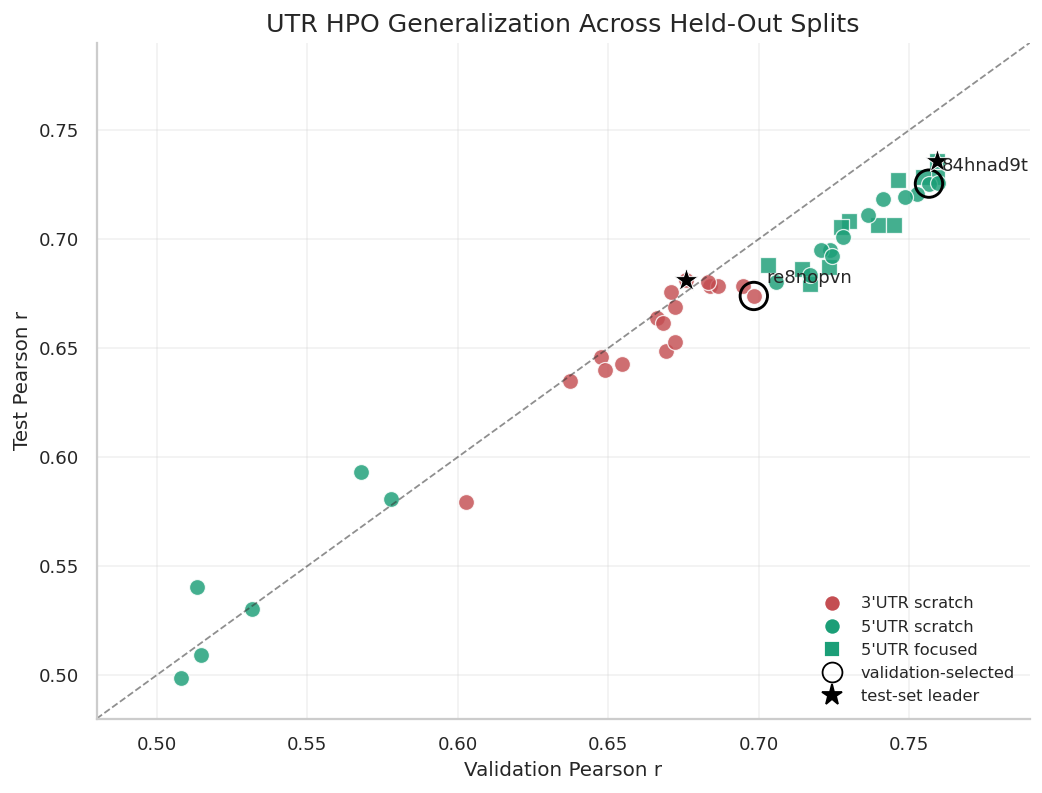

In [7]:
utr_runs = public_runs[public_runs["task_family"].isin(["utr5", "utr3"]) & public_runs["test_r2"].notna()].copy()

fig, ax = plt.subplots(figsize=(8.2, 6.2))
marker_by_phase = {"Scratch / broad HPO": "o", "Focused HPO": "s"}

for (region, phase), sub in utr_runs.groupby(["region", "search_phase"], observed=True):
    ax.scatter(
        sub["val_pearson"], sub["test_pearson"],
        s=78,
        color=REGION_COLORS[region],
        marker=marker_by_phase[phase],
        edgecolor="white",
        linewidth=0.7,
        alpha=0.82,
        label=f"{region} - {phase}",
    )

for _, row in validation_winners[validation_winners["region"].isin(["5'UTR", "3'UTR"])].iterrows():
    ax.scatter(row["val_pearson"], row["test_pearson"], s=230, facecolors="none", edgecolors="black", linewidths=1.6)
    ax.annotate(row["run_id"], (row["val_pearson"], row["test_pearson"]), xytext=(7, 7), textcoords="offset points", fontsize=10)

for _, row in test_winners.iterrows():
    ax.scatter(row["val_pearson"], row["test_pearson"], s=190, marker="*", color="black", edgecolor="white", linewidth=0.5)

lims = [0.48, 0.79]
ax.plot(lims, lims, color="#333333", linestyle="--", linewidth=1, alpha=0.55)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Validation Pearson r")
ax.set_ylabel("Test Pearson r")
ax.set_title("UTR HPO Generalization Across Held-Out Splits")
ax.grid(alpha=0.25)

handles = [
    Line2D([0], [0], marker="o", color="w", label="3'UTR scratch", markerfacecolor=REGION_COLORS["3'UTR"], markeredgecolor="white", markersize=9),
    Line2D([0], [0], marker="o", color="w", label="5'UTR scratch", markerfacecolor=REGION_COLORS["5'UTR"], markeredgecolor="white", markersize=9),
    Line2D([0], [0], marker="s", color="w", label="5'UTR focused", markerfacecolor=REGION_COLORS["5'UTR"], markeredgecolor="white", markersize=9),
    Line2D([0], [0], marker="o", color="black", label="validation-selected", markerfacecolor="none", markersize=11, linestyle="None"),
    Line2D([0], [0], marker="*", color="black", label="test-set leader", markerfacecolor="black", markersize=12, linestyle="None"),
]
ax.legend(handles=handles, frameon=False, loc="lower right")
fig.tight_layout()

for ext in ["png", "svg"]:
    fig.savefig(OUT_DIR / f"utr_validation_vs_test_pearson.{ext}", bbox_inches="tight")
plt.show()

## Plot 3 - Region Winner Summary

This is the most slide-friendly single panel: validation-selected winners, validation metrics, and UTR test metrics together. Promoter has no populated test column in the current registry export.

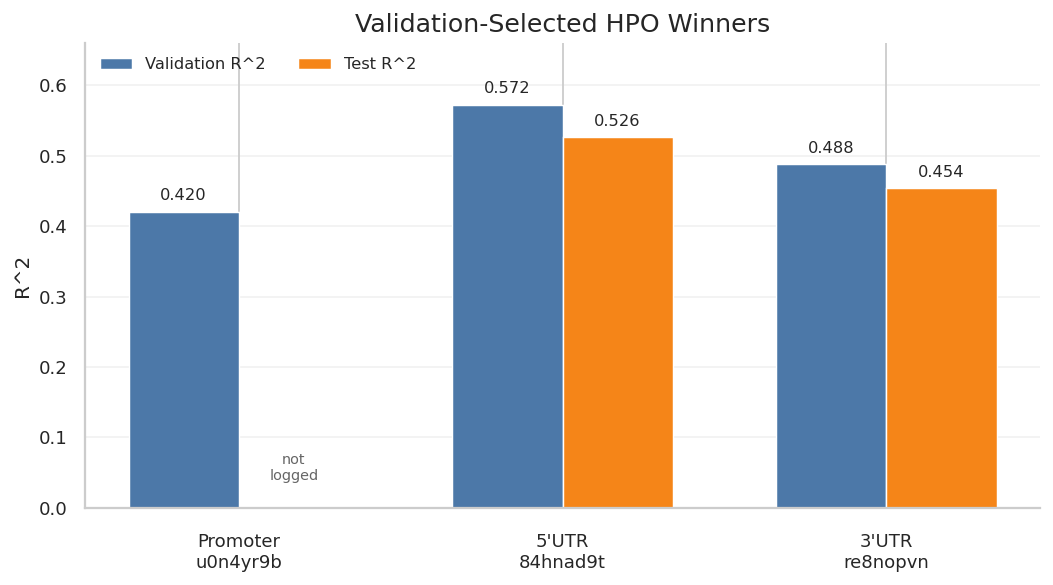

In [8]:
winner_long = []
for _, row in validation_winners.iterrows():
    winner_long.append({"region": row["region"], "metric": "Validation R^2", "value": row["val_r2"], "run_id": row["run_id"]})
    if pd.notna(row["test_r2"]):
        winner_long.append({"region": row["region"], "metric": "Test R^2", "value": row["test_r2"], "run_id": row["run_id"]})
winner_long = pd.DataFrame(winner_long)
winner_long["region"] = pd.Categorical(winner_long["region"], REGION_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(8.2, 4.6))
x = np.arange(len(REGION_ORDER))
bar_width = 0.34
metric_colors = {"Validation R^2": "#4C78A8", "Test R^2": "#F58518"}

for i, metric in enumerate(["Validation R^2", "Test R^2"]):
    sub = winner_long[winner_long["metric"].eq(metric)].set_index("region")
    vals = [sub.loc[region, "value"] if region in sub.index else np.nan for region in REGION_ORDER]
    offsets = x + (i - 0.5) * bar_width
    bars = ax.bar(offsets, vals, width=bar_width, color=metric_colors[metric], label=metric, edgecolor="white", linewidth=0.8)
    for region, bar, val in zip(REGION_ORDER, bars, vals):
        if np.isfinite(val):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.012, f"{val:.3f}", ha="center", va="bottom", fontsize=9)
        elif metric == "Test R^2":
            ax.text(bar.get_x() + bar.get_width()/2, 0.035, "not\nlogged", ha="center", va="bottom", fontsize=8, color="#666666")

tick_labels = []
for region in REGION_ORDER:
    row = validation_winners[validation_winners["region"].eq(region)]
    run_id = row.iloc[0]["run_id"] if not row.empty else ""
    tick_labels.append(f"{region}\n{run_id}")

ax.set_xticks(x)
ax.set_xticklabels(tick_labels)
ax.tick_params(axis="x", pad=8)
ax.set_ylabel("R^2")
ax.set_title("Validation-Selected HPO Winners")
ax.set_ylim(0, 0.66)
ax.legend(frameon=False, loc="upper left", ncol=2)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()

for ext in ["png", "svg"]:
    fig.savefig(OUT_DIR / f"validation_selected_winner_summary.{ext}", bbox_inches="tight")
plt.show()

## Plot 4 - Top Five Runs Per Region

This plot is useful when presenting HPO stability: 5'UTR and 3'UTR have multiple close contenders, while promoter performance is clustered tightly near the current ceiling.

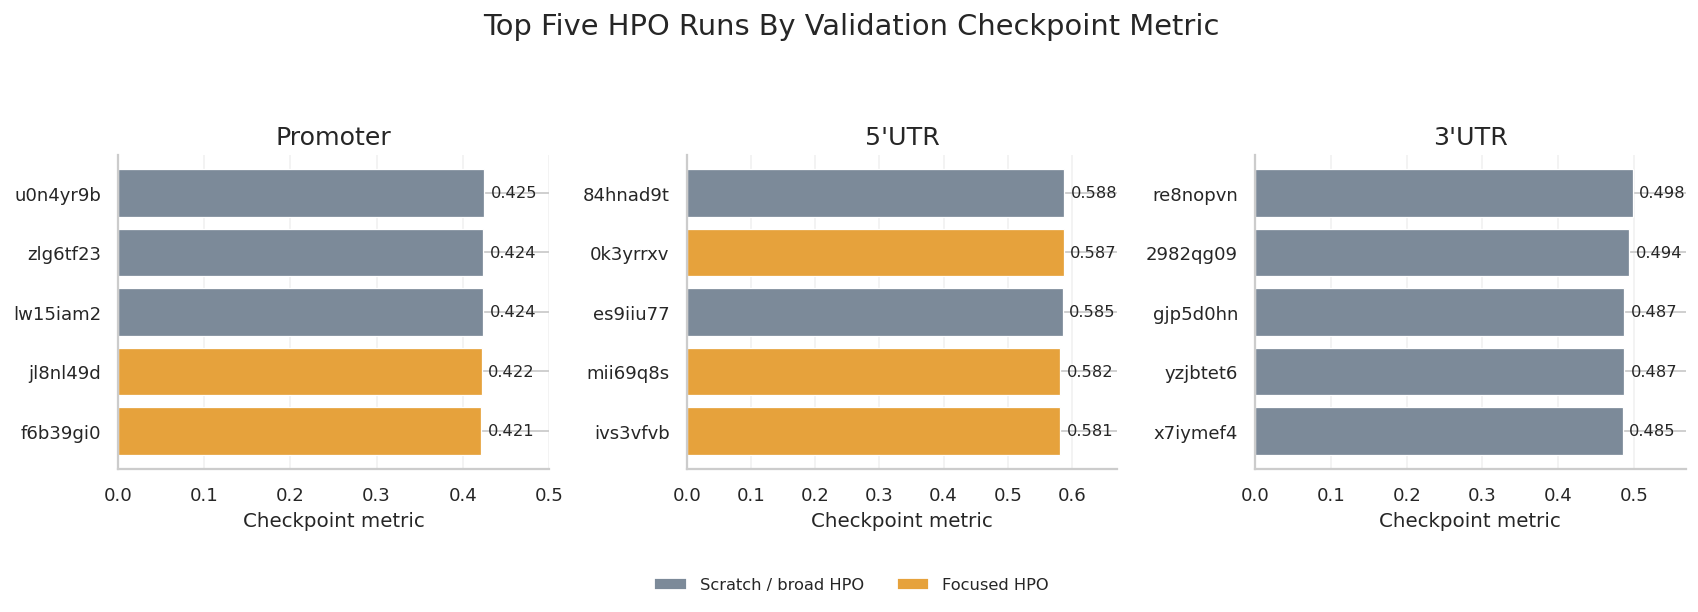

In [9]:
top5 = (
    public_runs.sort_values(["region", "checkpoint_metric"], ascending=[True, False])
    .groupby("region", group_keys=False)
    .head(5)
    .copy()
)
top5["region"] = pd.Categorical(top5["region"], REGION_ORDER, ordered=True)
top5 = top5.sort_values(["region", "checkpoint_metric"], ascending=[True, True])

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.4), sharex=False)
for ax, region in zip(axes, REGION_ORDER):
    sub = top5[top5["region"].eq(region)].copy()
    y = np.arange(len(sub))
    colors = [PHASE_COLORS[p] for p in sub["search_phase"]]
    ax.barh(y, sub["checkpoint_metric"], color=colors, edgecolor="white", linewidth=0.7)
    ax.set_yticks(y)
    ax.set_yticklabels(sub["run_id"])
    ax.set_title(region)
    ax.set_xlabel("Checkpoint metric")
    ax.grid(axis="x", alpha=0.25)
    xmax = max(sub["checkpoint_metric"].max() * 1.14, 0.5)
    ax.set_xlim(0, xmax)
    for yi, val in zip(y, sub["checkpoint_metric"]):
        ax.text(val + xmax * 0.015, yi, f"{val:.3f}", va="center", fontsize=9)

fig.suptitle("Top Five HPO Runs By Validation Checkpoint Metric", y=1.02, fontsize=16)
phase_handles = [Patch(facecolor=color, label=phase) for phase, color in PHASE_COLORS.items()]
fig.legend(handles=phase_handles, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=[0, 0.08, 1, 0.94])

for ext in ["png", "svg"]:
    fig.savefig(OUT_DIR / f"top5_checkpoint_metric_by_region.{ext}", bbox_inches="tight")
plt.show()

## Literature Context: PARADE Predictor

Sources used for this short comparison:

- Khoroshkin et al., *A generative framework for enhanced cell-type specificity in rationally designed mRNAs*, bioRxiv 2024, DOI: [10.1101/2024.12.31.630783v1](https://www.biorxiv.org/content/10.1101/2024.12.31.630783v1)
- Official code repository: [autosome-ru/parade](https://github.com/autosome-ru/parade)
- Text mirror inspected for exact performance statements: [ResearchGate PDF page](https://www.researchgate.net/publication/387655881_A_generative_framework_for_enhanced_cell-type_specificity_in_rationally_designed_mRNAs)

Key setup differences:

- PARADE measured about 30,000 50 nt 5'UTRs and about 30,000 240 nt 3'UTRs across six cell lines, including HepG2.
- PARADE Predictor is a LegNet-based regression model with cell-type information as input. It predicts absolute activity in specific cell lines and activity deviation from the cross-cell average. Their paper also compares against k-mer count regression and Optimus-5-prime.
- The paper reports Pearson r of 0.65-0.79 for 5'UTR activity and 0.65-0.75 for 3'UTR activity on the Library 1 prediction task. On the designed Library 2 validation set, reported correlations are lower for 5'UTRs (0.39-0.62) and remain about 0.65-0.70 for 3'UTRs.
- Our local Hani UTR HPO uses only `target_cell_type: c2`, which the preprocessing notebook labels as HepG2. We predict one scalar `rna_activity` value after filtering to that cell type, using the saved `fold` split column.

So the comparison is useful for scale, but not an apples-to-apples benchmark: our task is narrower (one cell type, no specificity index or cross-cell activity deviation), while PARADE is explicitly designed for multi-cell activity and specificity.

,region,series,low,high,point,run_id
0,5'UTR,This HPO: validation-selected test Pearson r,0.725411,0.725411,0.725411,84hnad9t
1,3'UTR,This HPO: validation-selected test Pearson r,0.673881,0.673881,0.673881,re8nopvn
2,5'UTR,This HPO: test-set leader Pearson r,0.735808,0.735808,0.735808,0k3yrrxv
3,3'UTR,This HPO: test-set leader Pearson r,0.681379,0.681379,0.681379,x7iymef4
4,5'UTR,PARADE Library 1 reported Pearson r range,0.650000,0.790000,NaN,paper
5,3'UTR,PARADE Library 1 reported Pearson r range,0.650000,0.750000,NaN,paper
6,5'UTR,PARADE Library 2 reported Pearson r range,0.390000,0.620000,NaN,paper
7,3'UTR,PARADE Library 2 reported Pearson r range,0.650000,0.700000,NaN,paper


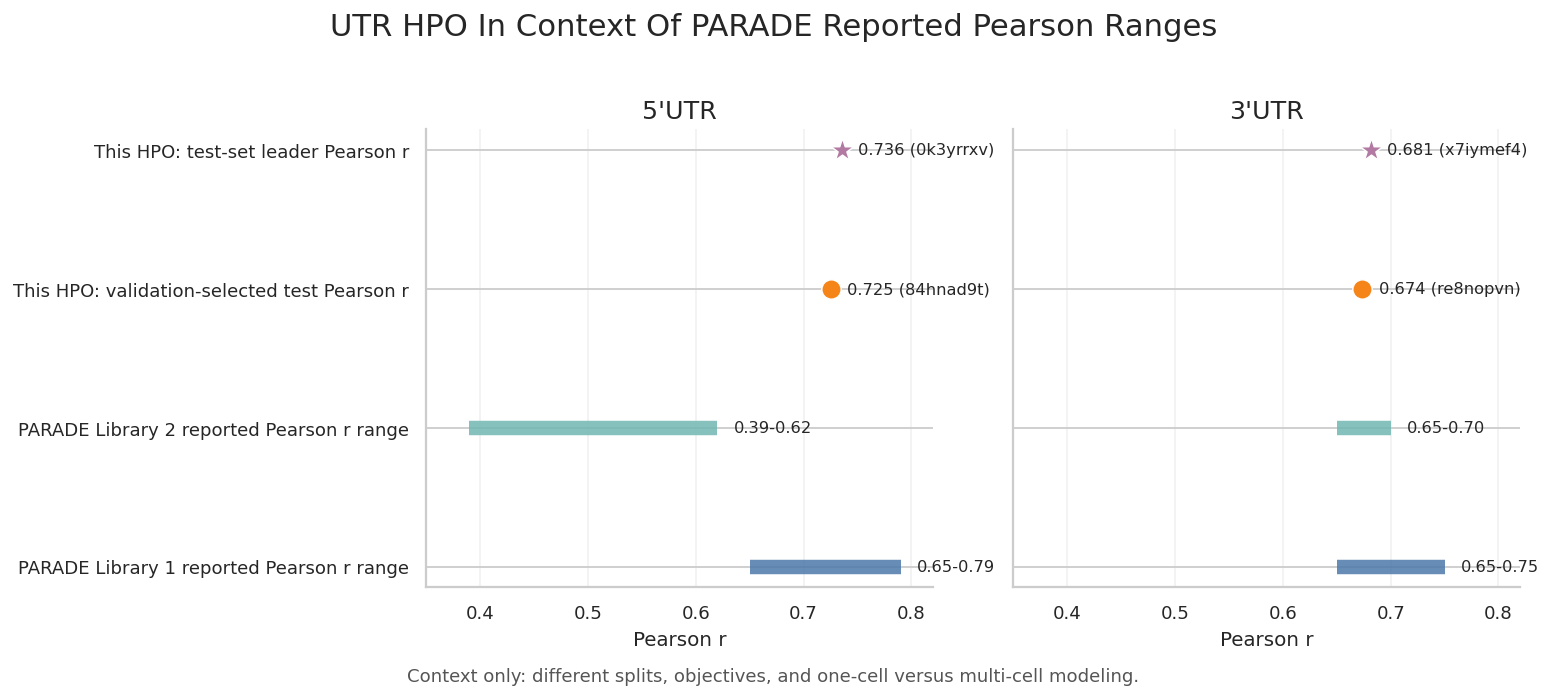

In [10]:
comparison_rows = []
for region in ["5'UTR", "3'UTR"]:
    row = validation_winners[validation_winners["region"].eq(region)].iloc[0]
    comparison_rows.append({
        "region": region,
        "series": "This HPO: validation-selected test Pearson r",
        "low": row["test_pearson"],
        "high": row["test_pearson"],
        "point": row["test_pearson"],
        "run_id": row["run_id"],
    })

for region in ["5'UTR", "3'UTR"]:
    row = test_winners[test_winners["region"].eq(region)].iloc[0]
    comparison_rows.append({
        "region": region,
        "series": "This HPO: test-set leader Pearson r",
        "low": row["test_pearson"],
        "high": row["test_pearson"],
        "point": row["test_pearson"],
        "run_id": row["run_id"],
    })

comparison_rows.extend([
    {"region": "5'UTR", "series": "PARADE Library 1 reported Pearson r range", "low": 0.65, "high": 0.79, "point": np.nan, "run_id": "paper"},
    {"region": "3'UTR", "series": "PARADE Library 1 reported Pearson r range", "low": 0.65, "high": 0.75, "point": np.nan, "run_id": "paper"},
    {"region": "5'UTR", "series": "PARADE Library 2 reported Pearson r range", "low": 0.39, "high": 0.62, "point": np.nan, "run_id": "paper"},
    {"region": "3'UTR", "series": "PARADE Library 2 reported Pearson r range", "low": 0.65, "high": 0.70, "point": np.nan, "run_id": "paper"},
])
comparison = pd.DataFrame(comparison_rows)
display(comparison)
comparison.to_csv(OUT_DIR / "utr_parade_context_comparison.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.9), sharex=True)
series_order = [
    "PARADE Library 1 reported Pearson r range",
    "PARADE Library 2 reported Pearson r range",
    "This HPO: validation-selected test Pearson r",
    "This HPO: test-set leader Pearson r",
]
series_colors = {
    "PARADE Library 1 reported Pearson r range": "#4C78A8",
    "PARADE Library 2 reported Pearson r range": "#72B7B2",
    "This HPO: validation-selected test Pearson r": "#F58518",
    "This HPO: test-set leader Pearson r": "#B279A2",
}

for ax, region in zip(axes, ["5'UTR", "3'UTR"]):
    sub = comparison[comparison["region"].eq(region)].set_index("series")
    for yi, series in enumerate(series_order):
        row = sub.loc[series]
        color = series_colors[series]
        if row["low"] == row["high"]:
            marker = "o" if "validation" in series else "*"
            size = 115 if marker == "o" else 180
            ax.scatter(row["point"], yi, color=color, s=size, marker=marker, edgecolor="white", linewidth=0.8, zorder=3)
            ax.text(row["point"] + 0.015, yi, f"{row['point']:.3f} ({row['run_id']})", va="center", fontsize=9)
        else:
            ax.hlines(yi, row["low"], row["high"], color=color, linewidth=8, alpha=0.85)
            ax.text(row["high"] + 0.015, yi, f"{row['low']:.2f}-{row['high']:.2f}", va="center", fontsize=9)
    ax.set_yticks(range(len(series_order)))
    ax.set_yticklabels(series_order if region == "5'UTR" else [])
    ax.set_title(region)
    ax.set_xlabel("Pearson r")
    ax.set_xlim(0.35, 0.82)
    ax.grid(axis="x", alpha=0.25)

fig.suptitle("UTR HPO In Context Of PARADE Reported Pearson Ranges", y=1.03, fontsize=17)
fig.text(0.5, -0.02, "Context only: different splits, objectives, and one-cell versus multi-cell modeling.", ha="center", fontsize=10, color="#555555")
fig.tight_layout()

for ext in ["png", "svg"]:
    fig.savefig(OUT_DIR / f"utr_parade_context_comparison.{ext}", bbox_inches="tight")
plt.show()

## Suggested Slide Wording

Our updated public-data HPO runs put the Hani one-cell UTR models in the same broad performance regime as the PARADE activity predictor, but the tasks are not equivalent. PARADE trains a LegNet-based predictor across six cell lines and explicitly models cell-type activity differences; our preprocessing filters to c2/HepG2 and trains a single-output CNN on `rna_activity` for that one cell type.

For 5'UTR, the strongest focused HPO model is `0k3yrrxv`, with test Pearson r = 0.736 and test R^2 = 0.541. That falls inside PARADE's reported Library 1 5'UTR Pearson range of 0.65-0.79, but it should be described as HepG2-only activity prediction rather than cell-type-specific UTR modeling.

For 3'UTR, the validation-selected winner is `re8nopvn`, with test Pearson r = 0.674 and test R^2 = 0.454. The literal best test run, `x7iymef4`, reaches test Pearson r = 0.681 and test R^2 = 0.464. This is near the lower half of PARADE's reported 3'UTR Library 1 range of 0.65-0.75, again under a simpler one-cell target. The practical takeaway is that our one-cell HPO models are credible for scalar activity prediction, while claims about specificity or cross-cell design would require extending the preprocessing/modeling to multiple cell types.

In [11]:
print("Saved files:")
for path in sorted(OUT_DIR.glob("*")):
    print(path.relative_to(REPO_ROOT))

Saved files:
boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/best_r2_by_region_any_split.csv
boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/best_r2_by_region_any_split.png
boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/best_r2_by_region_any_split.svg
boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/best_test_performance_by_region.csv
boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/best_test_performance_by_region.png
boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/best_test_performance_by_region.svg
boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/best_validation_by_region_phase.png
boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/best_validation_by_region_phase.svg
boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/top5_checkpoint_me